# sdata DoE

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%autosave 0
    
import logging
logging.basicConfig(format='%(asctime)s %(levelname)s:%(message)s', level=logging.WARNING, datefmt='%I:%M:%S')

import os
import sdata
import sdata.doe
print("sdata v{}".format(sdata.__version__))

Autosave disabled
sdata v0.19.0


In [2]:
params_ranges = {"a":[1,2],
"b":[10,20],
"c":[-1,1],
"d":[1,10]}

In [3]:
doe = sdata.doe.DOE(params_ranges)
b = doe._ranges["b"]
b

[10.0 , 20.0]

In [4]:
doe.gen_sobol01(n=3)

,a,b,c,d
doe_id,,,,
1,0.50,0.50,0.50,0.50
2,0.75,0.25,0.75,0.25
3,0.25,0.75,0.25,0.75


In [5]:
doe.gen_sobol(n=3)

,a,b,c,d
doe_id,,,,
1,1.50,15.0,0.0,5.50
2,1.75,12.5,0.5,3.25
3,1.25,17.5,-0.5,7.75


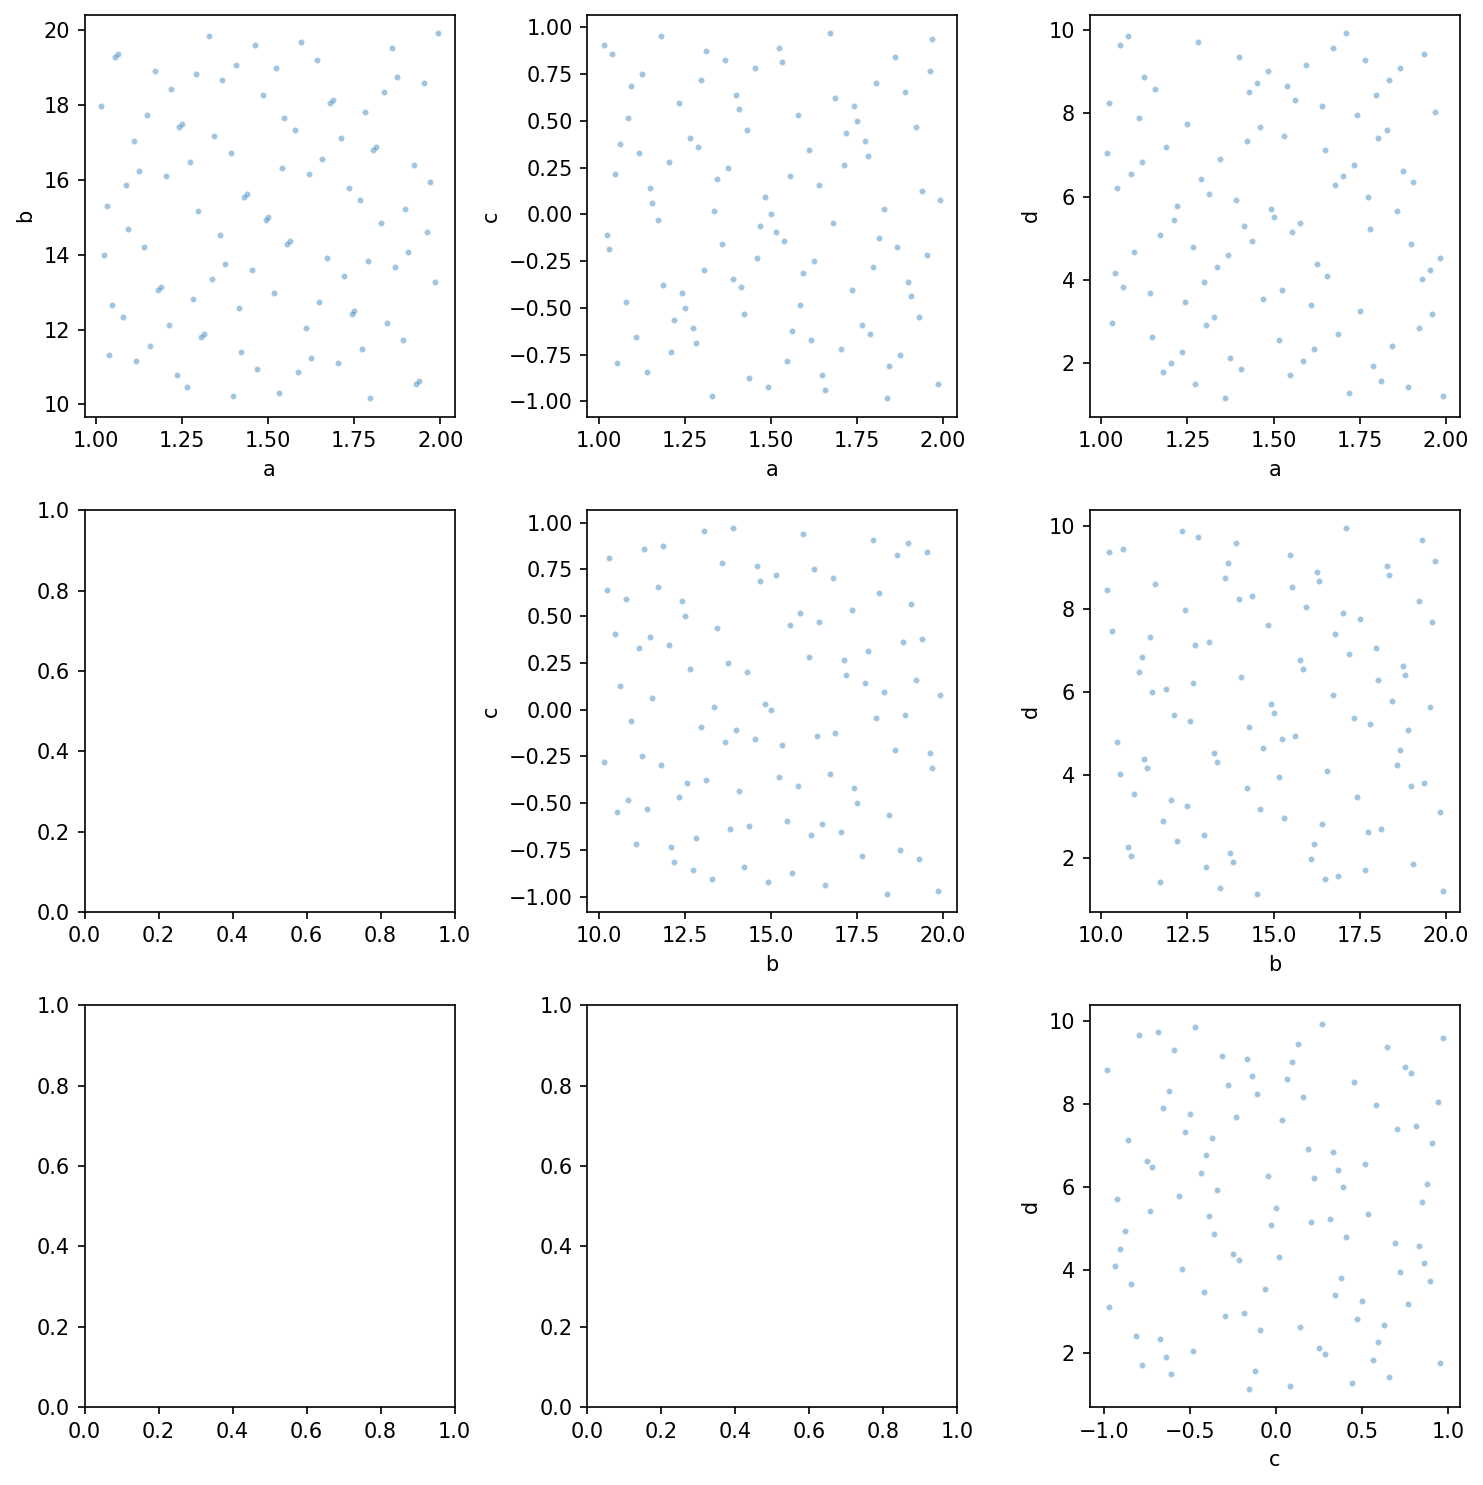

In [6]:
sdata.doe.plot_doe(doe.gen_sobol(n=100), s=4, figsize=(10,10), alpha=.3)

In [25]:
doe.ranges

OrderedDict([('a', [1.0 , 2.0]),
             ('b', [10.0 , 20.0]),
             ('c', [-1.0 , 1.0]),
             ('d', [1.0 , 10.0])])

In [26]:
df_doe = doe.gen_sobol(n=30)
df_doe.head(2)

,a,b,c,d
doe_id,,,,
1,1.50,15.0,0.0,5.50
2,1.75,12.5,0.5,3.25


In [27]:
import pandas as pd
df = pd.DataFrame()
type(df.index.name)

NoneType

In [32]:
data = doe.to_data(name="test", df_doe=df_doe)
print(data)
data.metadata.udf

(Data 'test':2a6c5b416cd04bd6888c394b90fdefc8)


,name,value,dtype,unit,description,label,required
key,,,,,,,
a,a,"[1.0 , 2.0]",str,?,parameter range a,$a$,False
b,b,"[10.0 , 20.0]",str,?,parameter range b,$b$,False
c,c,"[-1.0 , 1.0]",str,?,parameter range c,$c$,False
d,d,"[1.0 , 10.0]",str,?,parameter range d,$d$,False


In [18]:
data = sdata.Data(name="doe", uuid=None, table=df_doe, description="my DoE")
for parameter_name, r in doe.ranges.items():
    data.metadata.add(parameter_name, r, unit="?", description=f"parameter range {parameter_name}", 
                      label=rf"${parameter_name}$")
data.metadata.udf

,name,value,dtype,unit,description,label,required
key,,,,,,,
a,a,"[1.0 , 2.0]",str,?,parameter range a,$a$,False
b,b,"[10.0 , 20.0]",str,?,parameter range b,$b$,False
c,c,"[-1.0 , 1.0]",str,?,parameter range c,$c$,False
d,d,"[1.0 , 10.0]",str,?,parameter range d,$d$,False


In [19]:
data.df.head()

,a,b,c,d
doe_id,,,,
1,1.500,15.00,0.00,5.500
2,1.750,12.50,0.50,3.250
3,1.250,17.50,-0.50,7.750
4,1.375,13.75,0.25,2.125
5,1.875,18.75,-0.75,6.625


In [20]:
data.to_xlsx("/tmp/doe.xlsx")

In [21]:
data.df.head()

,a,b,c,d
doe_id,,,,
1,1.500,15.00,0.00,5.500
2,1.750,12.50,0.50,3.250
3,1.250,17.50,-0.50,7.750
4,1.375,13.75,0.25,2.125
5,1.875,18.75,-0.75,6.625


In [22]:
params_ranges = {"dummy1":[0,1],
"dummy2":[0,1],
"dummy3":[0,1],
"dummy4":[0,1],
"sheet_thickness": [0.8, 1.8],
 "slant_depth": [10., 50.],
 "angle_slant": [2., 8.],
 "r_die": [3., 6.],
 "r_punch": [4., 8.],
 "x_napf": [150, 250],
 "y_napf": [100, 150],

 "dwb_force": [100, 800],
 "blkh_force": [10000, 100000],

 "e": [200000, 210000],
 "r": [0.8, 1.5],
 "sigy": [230, 400],
 "tenst": [500, 1000]
 }
params_ranges.keys()

dict_keys(['dummy1', 'dummy2', 'dummy3', 'dummy4', 'sheet_thickness', 'slant_depth', 'angle_slant', 'r_die', 'r_punch', 'x_napf', 'y_napf', 'dwb_force', 'blkh_force', 'e', 'r', 'sigy', 'tenst'])

In [9]:
doe = sdata.doe.DOE(params_ranges)
sigy = doe._ranges["sigy"]
sigy

[230.0 , 400.0]

In [11]:
doe.gen_sobol01(n=3)

,dummy1,dummy2,dummy3,dummy4,sheet_thickness,slant_depth,angle_slant,r_die,r_punch,x_napf,y_napf,dwb_force,blkh_force,e,r,sigy,tenst
doe_id,,,,,,,,,,,,,,,,,
1,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50
2,0.75,0.25,0.75,0.25,0.75,0.25,0.75,0.25,0.25,0.75,0.25,0.75,0.25,0.75,0.25,0.75,0.75
3,0.25,0.75,0.25,0.75,0.25,0.75,0.25,0.75,0.75,0.25,0.75,0.25,0.75,0.25,0.75,0.25,0.25


In [12]:
doe.gen_sobol(n=3)

,dummy1,dummy2,dummy3,dummy4,sheet_thickness,slant_depth,angle_slant,r_die,r_punch,x_napf,y_napf,dwb_force,blkh_force,e,r,sigy,tenst
doe_id,,,,,,,,,,,,,,,,,
1,0.50,0.50,0.50,0.50,1.30,30.0,5.0,4.50,6.0,200.0,125.0,450.0,55000.0,205000.0,1.150,315.0,750.0
2,0.75,0.25,0.75,0.25,1.55,20.0,6.5,3.75,5.0,225.0,112.5,625.0,32500.0,207500.0,0.975,357.5,875.0
3,0.25,0.75,0.25,0.75,1.05,40.0,3.5,5.25,7.0,175.0,137.5,275.0,77500.0,202500.0,1.325,272.5,625.0


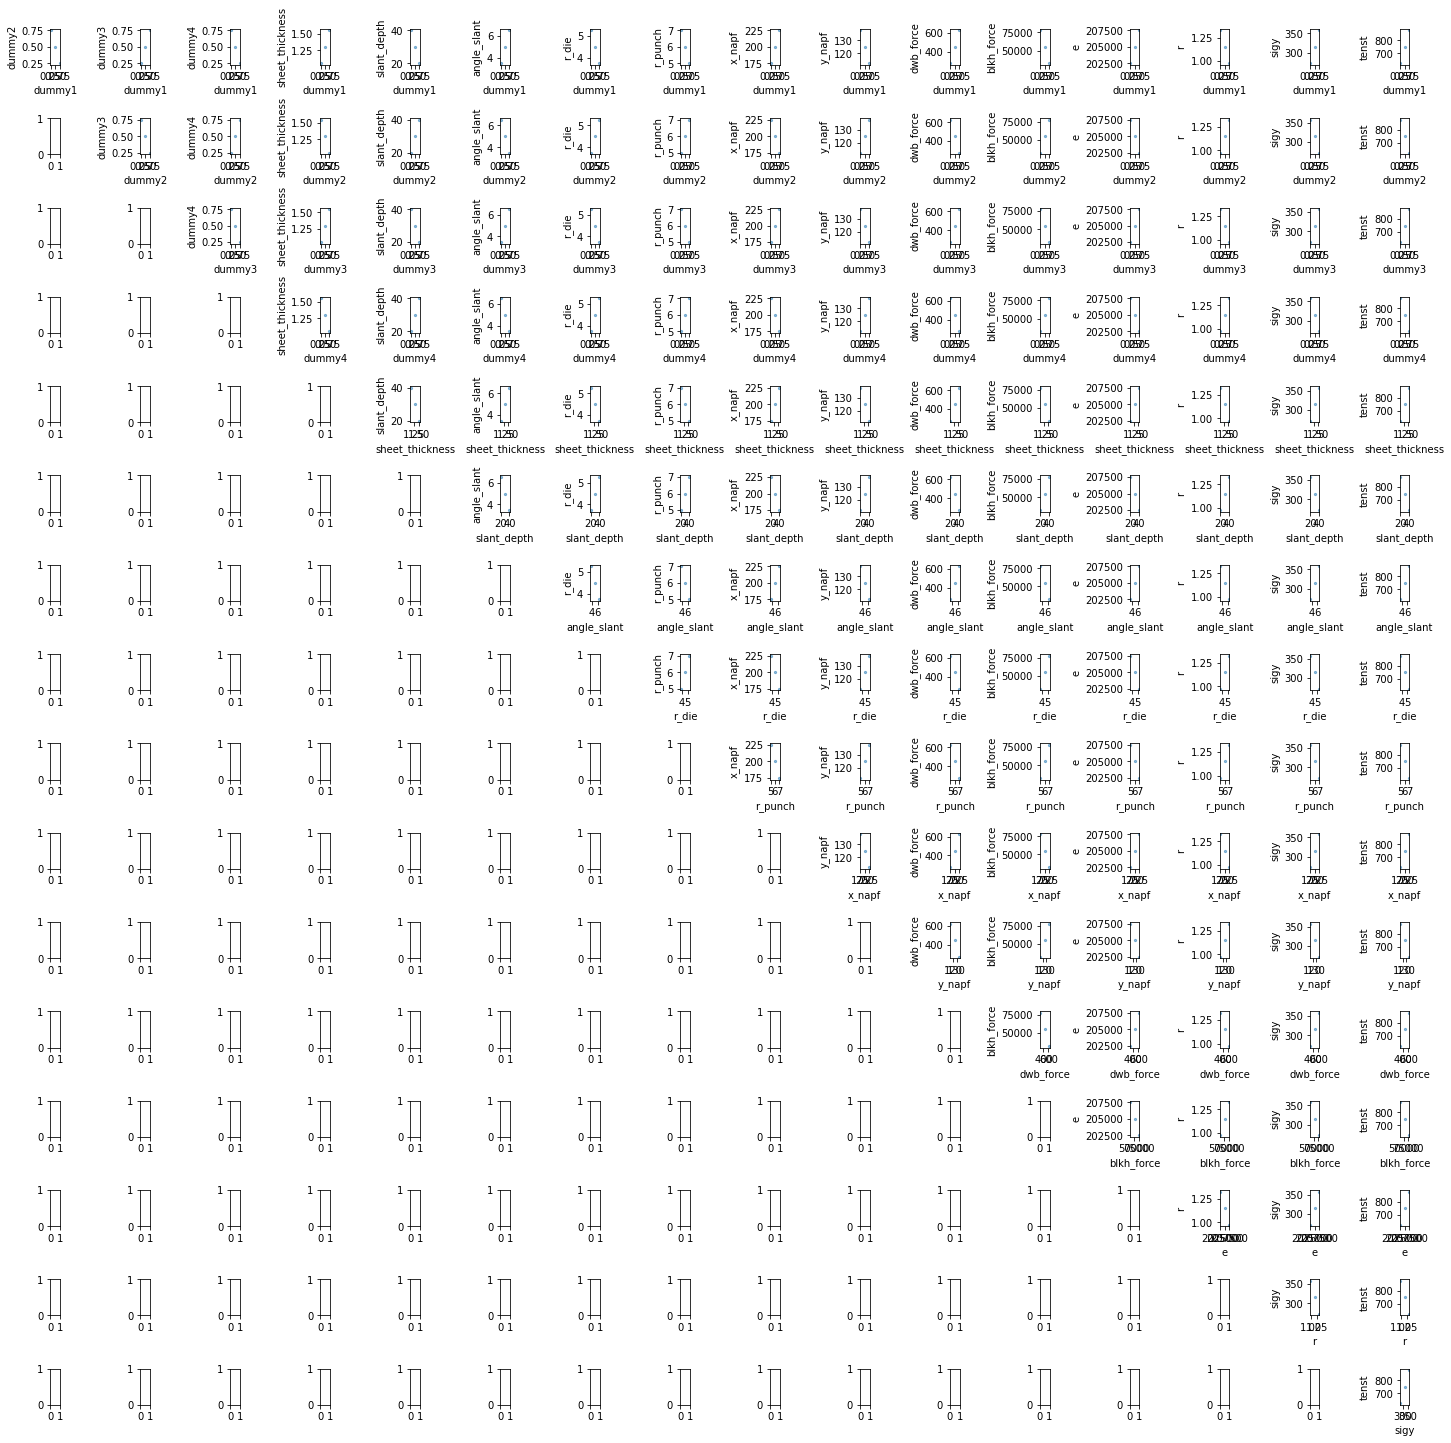

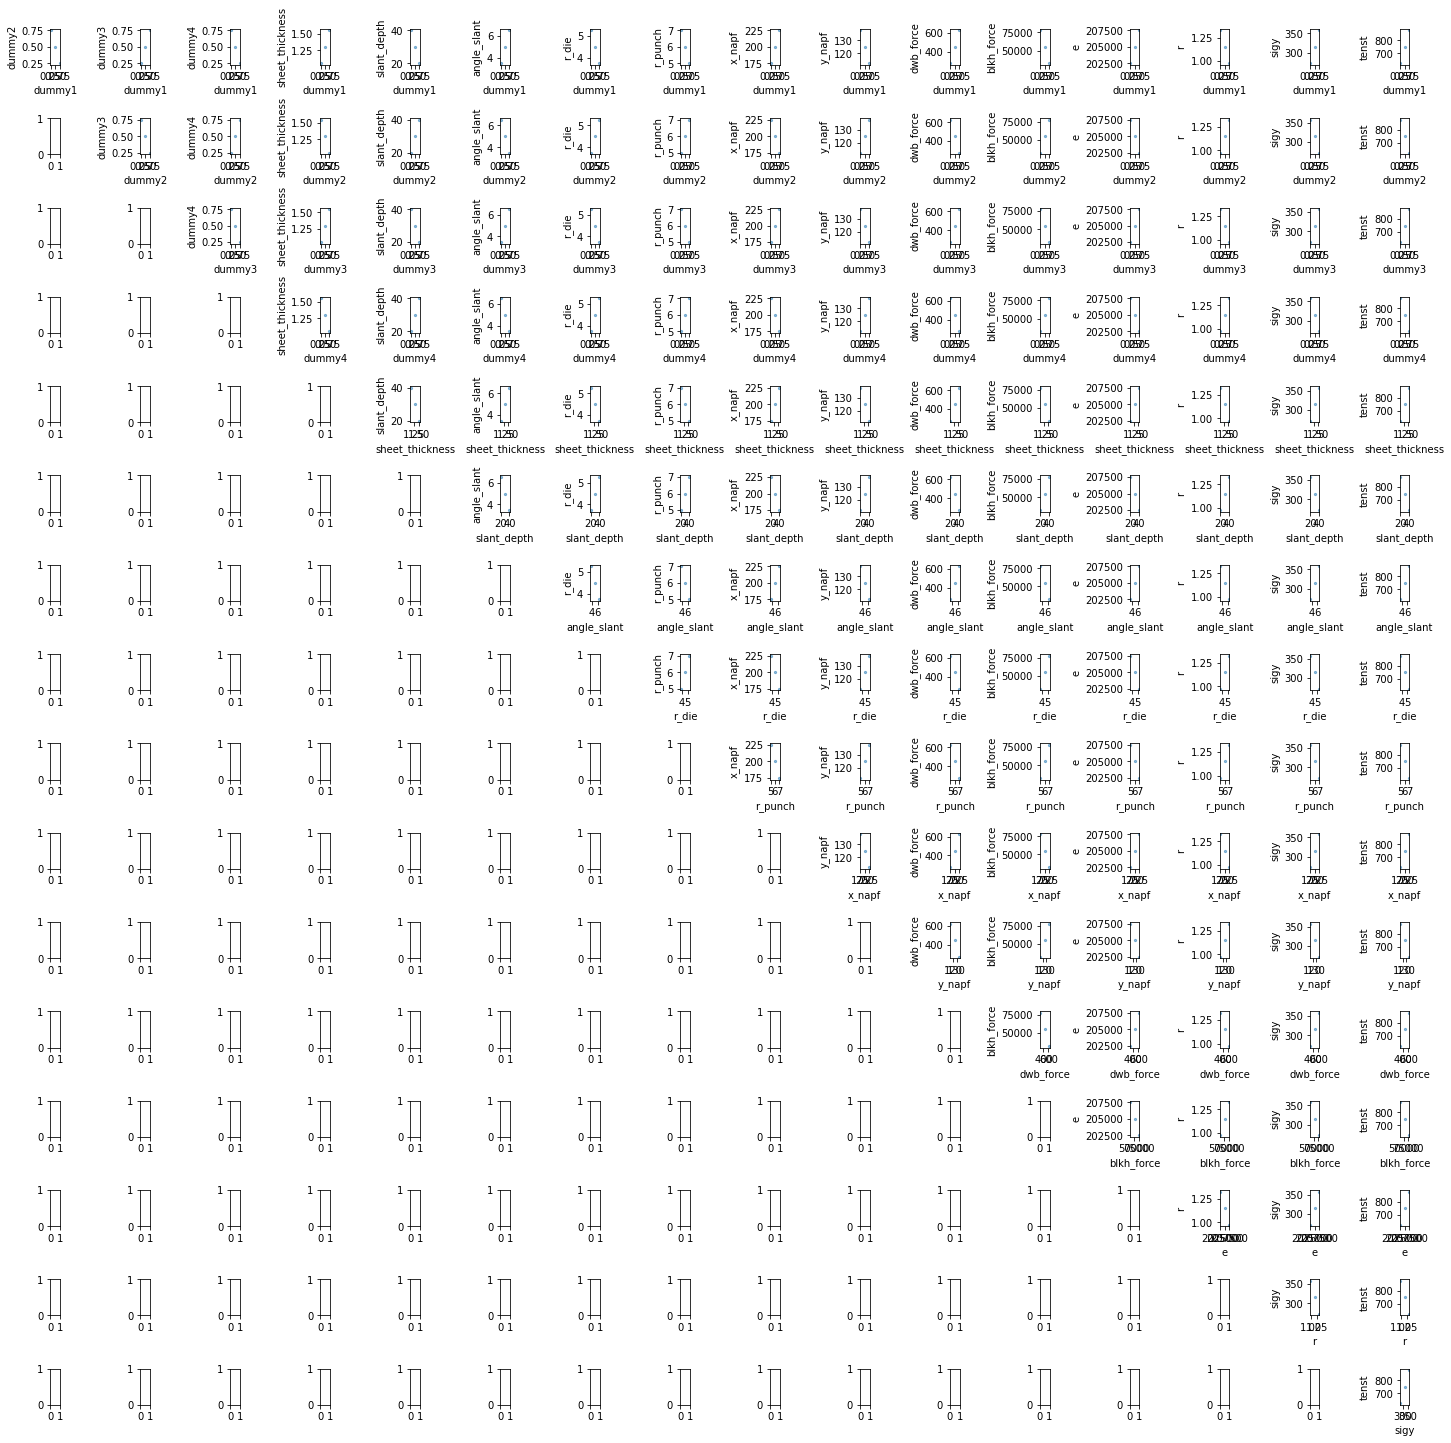

In [16]:
from itertools import combinations
import matplotlib.pyplot as plt
def plot_doe(df, figsize=(20,20)):
    dim_num = len(df.columns)
    fig, axs = plt.subplots(dim_num-1, dim_num-1, figsize=figsize)
    for i, j in list(combinations(range(dim_num), 2)):
        xi = df.columns[i]
        xj = df.columns[j]
        axs[i][j-1].scatter(df.iloc[:,i], df.iloc[:,j], alpha=.5, s=5)
        axs[i][j-1].set_xlabel(xi)
        axs[i][j-1].set_ylabel(xj)
    fig.tight_layout()
    return fig
plot_doe(doe.gen_sobol(n=3))